In [1]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM
import transformers
import gc

c:\Users\vanir\miniconda3\envs\moeLoRA\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
x = 10
tensor = torch.arange(0,x).reshape(2,5)
ls = torch.tensor([i*10 for i in range(0, x)])
x = ls[tensor[...,:]]
x_norms = x.norm(dim=-2)
print(x_norms)

RuntimeError: shape '[2, 5]' is invalid for input of size 12

In [31]:
seed = 10000
d = 100
rng = torch.Generator(device='cpu')
rng.manual_seed(seed)
tensor = torch.randn(d,d, generator=rng, dtype=torch.float32)
print(torch.matmul(tensor, tensor.T))

tensor([[115.5519,  14.1506,  16.1718,  ..., -21.8027,  11.9192,   8.1912],
        [ 14.1506, 110.9099,  20.6020,  ...,   0.5121,   7.6452,  -0.6304],
        [ 16.1718,  20.6020, 104.2005,  ..., -17.7482,   4.5209,   7.7929],
        ...,
        [-21.8027,   0.5121, -17.7482,  ...,  94.0081,   4.0012,   2.2460],
        [ 11.9192,   7.6452,   4.5209,  ...,   4.0012, 130.6390,  -4.6450],
        [  8.1912,  -0.6304,   7.7929,  ...,   2.2460,  -4.6450,  95.1223]])


In [2]:
import os
os.environ["HF_HUB_DOWNLOAD_TIMEOUT"]="60"
os.environ["HF_HUB_DISABLE_XET"] = "1"

In [3]:
try:
    del model
except:
    print("Model not loaded yet")
torch.cuda.empty_cache()
gc.collect()

Model not loaded yet


60

In [4]:
tokenizer = AutoTokenizer.from_pretrained('Qwen/Qwen2.5-3B-Instruct')

In [5]:
model = AutoModelForCausalLM.from_pretrained('Qwen/Qwen2.5-3B-Instruct', output_attentions=True).to('cuda')

The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 434/434 [00:00<00:00, 3346.31it/s]


In [6]:
text = """<think>\nOkay, let's try to solve this problem where I need to find all polynomials P(x, y) such that P(x, y) = P(x, x² - y) for every x and y. Hmm, so the polynomial is invariant when we replace y with x² - y. That seems like a symmetry condition. Let me think about how polynomials can satisfy such a condition.\n\nFirst, maybe I should start by considering the general form of a polynomial in two variables x and y. A polynomial in x and y can be written as a sum of terms like a_{ij}x^i y^j, where a_{ij} are coefficients. The condition given is that replacing y with x² - y doesn't change the polynomial. So if I substitute x² - y in place of y in P(x, y), the resulting polynomial should be the same as the original.\n\nLet me write this out. Let’s suppose P(x, y) = Σ_{i,j} a_{ij} x^i y^j. Then, replacing y by x² - y gives P(x, x² - y) = Σ_{i,j} a_{ij} x^i (x² - y)^j. The equation P(x, y) = P(x, x² - y) implies that each coefficient of x^i y^j in the original polynomial must equal the corresponding coefficient in the transformed polynomial after expansion.\n\nThis might be complicated to handle term by term, but maybe there's a smarter approach. Let me consider that if we substitute y with x² - y, then doing this substitution twice should bring us back to the original y. Because if I replace y with x² - y once, and then do it again, the second substitution would replace y with x² - (x² - y) = y. So applying the substitution twice is the identity transformation. Therefore, this substitution is an involution.\n\nThis suggests that the polynomial can be written in terms of invariants under this substitution. In other words, the polynomial should be expressible using functions (or variables) that are invariant when y is replaced by x² - y. So perhaps if I can find a set of generators for the invariant polynomials under this substitution, then P(x, y) must be a polynomial in those generators.\n\nWhat's an invariant under y ↦ x² - y? Let's see. If I can find some combination of x and y that doesn't change when y is replaced by x² - y. Let me try to find such an invariant. Let's denote the substitution as σ: y → x² - y. Then, applying σ once, y becomes x² - y. Applying σ again, it becomes x² - (x² - y) = y. So σ is indeed an involution.\n\nWhat's fixed by σ? Suppose there's a function f(x, y) such that f(x, y) = f(x, x² - y). Then f is invariant under σ. Let's try to find such a function. For example, consider f(y) = y + (x² - y) = x². Wait, that's just x². Wait, that's a trivial invariant. But actually, if we take the sum y + (x² - y) = x², that's x². But perhaps a better approach is to find something like y*(x² - y) or y + (x² - y) or maybe some combination.\n\nAlternatively, if we think of σ as an involution, the invariants would be polynomials in variables that are fixed by σ. Let’s consider that the substitution σ: y ↦ x² - y. If we can find a variable substitution that makes σ act as a reflection, maybe we can separate variables.\n\nLet’s set z = y - (x² / 2). Then, let's see what σ does to z. If y becomes x² - y, then z becomes (x² - y) - (x² / 2) = x²/2 - y. But z was originally y - x²/2. So under σ, z ↦ -z. Because:\n\nOriginal z: z = y - x²/2\n\nAfter substitution: σ(z) = (x² - y) - x²/2 = x²/2 - y = -(y - x²/2) = -z.\n\nSo z ↦ -z under the substitution. Therefore, any polynomial invariant under σ must be a polynomial in variables that are even in z. Because if you have a term with an odd power of z, it would change sign under σ, which would not preserve the polynomial unless the coefficient is zero.\n\nTherefore, the invariant polynomials under σ are precisely those polynomials that can be expressed in terms of x and z², since z² is invariant (as (-z)^2 = z²). Since z = y - x²/2, then z² = (y - x²/2)^2. Therefore, any polynomial in x and z² would be invariant under σ. Hence, the general solution is that P(x, y) is a polynomial in x and (y - x²/2)^2.\n\nAlternatively, we can write this as P(x, y) = Q(x, (y - x²/2)^2), where Q is any polynomial in two variables. Let me verify this.\n\nSuppose P(x, y) = Q(x, (y - x²/2)^2). Then, substituting y with x² - y gives:\n\nP(x, x² - y) = Q(x, ( (x² - y) - x²/2 )² ) = Q(x, (x²/2 - y)^2 ) = Q(x, (y - x²/2)^2 ) = P(x, y). So yes, this works.\n\nConversely, if P(x, y) is invariant under substitution y ↦ x² - y, then writing z = y - x²/2, so that substitution becomes z ↦ -z, then the invariants are polynomials in z² and x. Hence, P must be a polynomial in x and z², which is exactly the form above. Therefore, the general solution is P(x, y) = Q(x, (y - x²/2)^2), where Q is any polynomial in two variables.\n\nWait, but let me check if there are other invariants. Suppose I try to create another invariant function. Since we have x and z², maybe higher powers or combinations, but since Q is an arbitrary polynomial, that covers all possibilities. So the answer should be all polynomials in x and (y - x²/2)^2.\n\nAlternatively, maybe we can express this in terms of y and x² - y. Let me check. Let me try an example. Suppose Q(x, t) = t, then P(x, y) = (y - x²/2)^2. Let's compute P(x, x² - y) = ( (x² - y) - x²/2 )² = (x²/2 - y)^2 = (y - x²/2)^2 = P(x, y). So yes, it works.\n\nAnother example: if Q(x, t) = x*t, then P(x, y) = x*(y - x²/2)^2. Then P(x, x² - y) = x*( (x² - y) - x²/2 )² = x*(x²/2 - y)^2 = x*(y - x²/2)^2 = same as P(x, y). So that works as well.\n\nWhat if Q is a constant? Then P is constant, which is also invariant. So yes, constants are included.\n\nTherefore, the conclusion is that all such polynomials P(x, y) can be written as polynomials in x and (y - x²/2)^2. So the answer is that P(x, y) is any polynomial in x and (y - x²/2)^2. Therefore, we can write the solution as polynomials in x and y - (x²)/2 squared.\n\nAlternatively, perhaps simplifying (y - x²/2)^2 as y² - x² y + x^4 /4, but since we can write it as that squared term, but in terms of the answer, expressing it in terms of (y - x²/2)^2 is acceptable.\n\nSo, putting it all together, the polynomials satisfying P(x, y) = P(x, x² - y) are exactly those of the form Q(x, (y - x²/2)^2) where Q is a polynomial in two variables. Therefore, the answer is all polynomials in x and (y - (x²)/2)^2.\n\n**Final Answer**\nThe polynomials are those in \\( x \\) and \\( \\left(y - \\frac{x^2}{2}\\right)^2 \\). Thus, the solution is \\boxed{P(x, y) = Q\\left(x, \\left(y - \\frac{x^2}{2}\\right)^2\\right)} where \\( Q \\) is any polynomial in two variables.\n</think>\n\nTo solve the problem of finding all polynomials \\( P(x, y) \\) such that \\( P(x, y) = P(x, x^2 - y) \\) for every \\( x \\) and \\( y \\), we start by considering the symmetry condition imposed by the substitution \\( y \\mapsto x^2 - y \\). This substitution is an involution, meaning applying it twice returns the original value. \n\nWe introduce the variable \\( z = y - \\frac{x^2}{2} \\). Under the substitution \\( y \\mapsto x^2 - y \\), \\( z \\) transforms as follows:\n\\[\nz \\mapsto (x^2 - y) - \\frac{x^2}{2} = \\frac{x^2}{2} - y = - \\left( y - \\frac{x^2}{2} \\right) = -z.\n\\]\nThus, \\( z \\mapsto -z \\) under the substitution. For a polynomial to be invariant under this substitution, it must be even in \\( z \\). Therefore, the polynomial can be expressed in terms of \\( x \\) and \\( z^2 \\).\n\nSince \\( z = y - \\frac{x^2}{2} \\), we have \\( z^2 = \\left( y - \\frac{x^2}{2} \\right)^2 \\). Hence, any polynomial invariant under the substitution \\( y \\mapsto x^2 - y \\) must be a polynomial in \\( x \\) and \\( \\left( y - \\frac{x^2}{2} \\right)^2 \\).\n\nThus, the solution is all polynomials \\( P(x, y) \\) that can be written in the form:\n\\[\nP(x, y) = Q\\left( x, \\left( y - \\frac{x^2}{2} \\right)^2 \\right),\n\\]\nwhere \\( Q \\) is any polynomial in two variables.\n\n\\[\n\\boxed{P(x, y) = Q\\left(x, \\left(y - \\frac{x^2}{2}\\right)^2\\right)}"""

In [7]:
encoded = tokenizer(text, return_tensors='pt')
print(encoded['input_ids'].shape)

torch.Size([1, 2381])


In [8]:
for name, param in model.named_parameters():
    print(name)

model.embed_tokens.weight
model.layers.0.self_attn.q_proj.weight
model.layers.0.self_attn.q_proj.bias
model.layers.0.self_attn.k_proj.weight
model.layers.0.self_attn.k_proj.bias
model.layers.0.self_attn.v_proj.weight
model.layers.0.self_attn.v_proj.bias
model.layers.0.self_attn.o_proj.weight
model.layers.0.mlp.gate_proj.weight
model.layers.0.mlp.up_proj.weight
model.layers.0.mlp.down_proj.weight
model.layers.0.input_layernorm.weight
model.layers.0.post_attention_layernorm.weight
model.layers.1.self_attn.q_proj.weight
model.layers.1.self_attn.q_proj.bias
model.layers.1.self_attn.k_proj.weight
model.layers.1.self_attn.k_proj.bias
model.layers.1.self_attn.v_proj.weight
model.layers.1.self_attn.v_proj.bias
model.layers.1.self_attn.o_proj.weight
model.layers.1.mlp.gate_proj.weight
model.layers.1.mlp.up_proj.weight
model.layers.1.mlp.down_proj.weight
model.layers.1.input_layernorm.weight
model.layers.1.post_attention_layernorm.weight
model.layers.2.self_attn.q_proj.weight
model.layers.2.self

In [9]:
crazy = 0
def inference(prompt):
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True    
    )
    TurboCache = TurboQuantCache()
    encoded = tokenizer(text, return_tensors='pt').to('cuda')
    model.eval()
    print("Starting inference\n")
    with torch.no_grad():
        output = model.generate(
            **encoded,
            max_new_tokens=500,
            temperature=0.7,
            pad_token_id=tokenizer.eos_token_id,
            past_key_values=TurboCache,
            use_cache=True, 
            return_dict_in_generate=True,
        )
        print(type(output.past_key_values))
        print(output.past_key_values)
        print(f"Final tokens: {output}")

        global crazy
        crazy = output.past_key_values    
        return tokenizer.decode(
            output[0],
            skip_special_tokens=True
        )

In [10]:
h = torch.zeros(3,3).to('cuda')

In [11]:
def hook(module, input, output):
    global h
    h = output

In [12]:
x = model.model.layers[0].self_attn.register_forward_hook(hook)
output = inference(text)
print(output[0])
x.remove()

Starting inference

<class 'TurboQ.TurboQuantLayer.TurboQuantCache'>
TurboQuantCache(layers=[TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, TurboQuantLayer])
Final tokens: GenerateDecoderOnlyOutput(sequences=tensor([[151644,   8948,    198,  ...,     59,    921,   2870]],
       device='cuda:0'), scores=None, logits=None, attentions=None, hidden_states=None, past_key_values=TurboQuantCache(layers=[TurboQuantLayer, TurboQuantLayer, TurboQuantLayer, 

In [13]:
crazy.layers[0].keys[0][0][3]

tensor([ 2.2500e+00,  2.0781e+00, -3.6250e+00, -1.7344e+00,  9.0234e-01,
        -8.5156e-01, -2.4062e+00,  9.5312e-01,  8.9844e-01,  6.0156e-01,
        -4.0312e+00, -5.3711e-02,  2.9688e+00,  7.8125e-03,  3.7812e+00,
        -2.5781e+00,  3.1562e+00,  2.5195e-01,  4.7070e-01,  8.0078e-01,
         2.5781e+00, -7.1875e-01,  1.7676e-01,  4.7656e-01, -2.0938e+00,
        -3.8574e-02,  1.7109e+00, -3.3438e+00, -4.5117e-01, -4.1748e-02,
        -1.1953e+00,  3.0664e-01,  5.5859e-01, -1.8750e-01,  2.3340e-01,
        -1.3281e-01,  4.8047e-01, -9.0625e-01, -3.0000e+00, -8.4375e-01,
         6.1328e-01,  4.3359e-01, -1.7676e-01,  1.4688e+00, -5.0391e-01,
         6.0547e-01, -8.0469e-01,  9.8438e-01, -6.5625e-01, -1.8750e+01,
        -5.1562e+00, -4.2812e+00,  7.3750e+00, -7.3750e+00,  2.2344e+00,
        -1.4438e+01,  1.3250e+01, -2.1750e+01,  5.0000e+00,  8.8125e+00,
        -3.3250e+01,  1.8625e+01,  4.2250e+01,  3.9531e+00, -4.2812e+00,
         2.1250e+00, -4.3750e-01,  2.4531e+00, -2.9

In [14]:
print(f"Qwen2 File:, {transformers.models.qwen2.modeling_qwen2.__file__}")

Qwen2 File:, c:\Users\vanir\miniconda3\envs\moeLoRA\lib\site-packages\transformers\models\qwen2\modeling_qwen2.py


In [15]:
print(model.config.num_attention_heads)      # query heads
print(model.config.num_key_value_heads)      # KV heads (GQA)
print(model.config.hidden_size)              # 2048
print(model.config.hidden_size // model.config.num_attention_heads)  # head_dim

16
2
2048
128


In [111]:
with open('model_config.txt', 'w') as f:
    f.write(str(model.config))
f.close()

In [112]:
print(model.config.num_attention_heads)     # e.g. 32
model.config.num_key_value_heads     # should be 2, matching your cache

16


2

In [113]:
a = torch.Tensor([[1],[4]])

In [154]:
vec = crazy.layers[11].keys

In [155]:
for i in range(0,32):
    print(f"{i}. {torch.max(crazy.layers[i].keys[0])}, avg: {torch.mean(crazy.layers[i].keys[0])} from shape: {crazy.layers[i].keys[0].shape}")

0. 94.0, avg: -0.123046875 from shape: torch.Size([2, 2899, 128])
1. 19.5, avg: -0.4609375 from shape: torch.Size([2, 2899, 128])
2. 20.25, avg: 0.46484375 from shape: torch.Size([2, 2899, 128])
3. 12.4375, avg: 0.0242919921875 from shape: torch.Size([2, 2899, 128])
4. 11.75, avg: 0.031494140625 from shape: torch.Size([2, 2899, 128])
5. 13.8125, avg: 0.019287109375 from shape: torch.Size([2, 2899, 128])
6. 14.0625, avg: -0.039794921875 from shape: torch.Size([2, 2899, 128])
7. 14.25, avg: 0.1259765625 from shape: torch.Size([2, 2899, 128])
8. 9.875, avg: -0.061767578125 from shape: torch.Size([2, 2899, 128])
9. 10.875, avg: -0.042236328125 from shape: torch.Size([2, 2899, 128])
10. 7.6875, avg: 0.00037384033203125 from shape: torch.Size([2, 2899, 128])
11. 13.8125, avg: 0.03369140625 from shape: torch.Size([2, 2899, 128])
12. 14.5, avg: -0.052978515625 from shape: torch.Size([2, 2899, 128])
13. 15.25, avg: 0.046142578125 from shape: torch.Size([2, 2899, 128])
14. 16.5, avg: -0.09960937

In [156]:
from scipy.stats import kstest

In [157]:
from TurboQ.TurboQuantOperations import TurboQuantOps
ops = TurboQuantOps()

In [158]:
n = 128
b = torch.empty([1,1,1,n], device='cuda')
b = b.random_(0,2)
b[b == 0] = -1

In [159]:
c = torch.empty([1,1,1,n], device='cuda')
c = c.random_(0,2)
c[c == 0] = -1

In [160]:
r = b*vec
r_rot = ops.FWHT(r, normalize=True)
# r_rot = r
r_rot.shape

Gonna normalize


torch.Size([1, 2, 2899, 128])

In [161]:
f = c*r_rot
f_rot = ops.FWHT(f, normalize=True)
# f_rot = f
# f_rot.shape

Gonna normalize


In [162]:
import matplotlib.pyplot as plt

(array([0.02415059, 0.06037647, 0.04830117, 0.10867764, 0.09660235,
        0.24150587, 0.25358117, 0.18112941, 0.14490352, 0.1932047 ,
        0.09660235, 0.09660239]),
 array([-4.25454712, -3.60756493, -2.96058273, -2.31360054, -1.66661835,
        -1.01963615, -0.37265396,  0.27432823,  0.92131042,  1.56829262,
         2.21527481,  2.862257  ,  3.50923896]),
 <BarContainer object of 12 artists>)

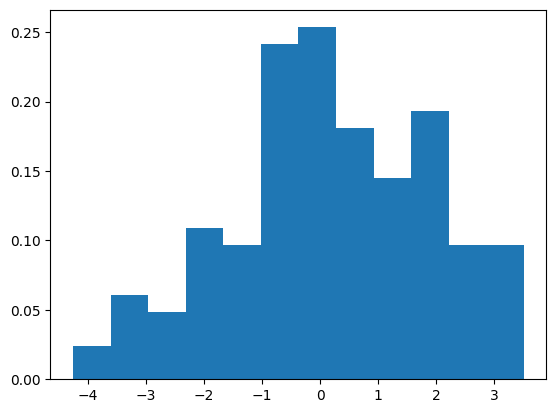

In [163]:
plt.hist(f_rot[0][0][2000].flatten().to(torch.float32).cpu().numpy(), bins=12, density=True)

In [168]:
import torch
from scipy.stats import kstest
from joblib import Parallel, delayed
import multiprocessing as mp
import math

# 1. Update the function to accept the 4th argument: dist_args
def single_ks_test(idx, sample, dist, dist_args):
    """Run one Kolmogorov-Smirnov test."""
    # 2. Pass dist_args into the kstest function
    result = kstest(sample, dist, args=dist_args)
    return idx, result.statistic, result.pvalue

dist = "norm"
n_cores = mp.cpu_count()
print(f"Using {n_cores} CPU cores")
# Assuming f_rot is defined in your notebook
args_list = []
for i in range(f_rot.shape[-2]): # Adjust your range
    sample = f_rot[0][0][i].flatten().to(torch.float32).cpu().numpy().copy()
    
    # Calculate the standard deviation just for this specific sample
    sample_sigma = sample.std() 
    
    # Pass this specific scalar to the arguments (4 elements total)
    args_list.append((i, sample, dist, (0, sample_sigma)))
        
# 3. Update the Joblib loop to unpack and pass all 4 variables
results = Parallel(n_jobs=n_cores)(
    delayed(single_ks_test)(idx, sample, dist, dist_args) 
    for idx, sample, dist, dist_args in args_list
)

failures = 0
dsum = 0
for i in results:
    if i[2] < 0.05:
        dsum += i[1]
        failures += 1 
print(f"Total Failures: {failures} out of {f_rot.shape[-2]}")
print(f"AVG Dsum: {dsum/failures}")

Using 16 CPU cores
Total Failures: 177 out of 2899
AVG Dsum: 0.12965215024534846
